# Pacman-with-coins safety abstraction demo

This demo supports the tutorial section immediately after **safety abstractions**.

The goals are:

1. inspect the Pacman-with-coins safety abstraction;
2. compare the task observation with the abstract safety state;
3. step through the environment while observing both concrete and abstract states;
4. highlight why the shield can ignore reward-only variables such as coin locations.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import inspect
import textwrap
import warnings
import pprint

# Make the notebook runnable when dropped into MASA-Safe-RL/tutorial/ or opened from repo root.
HERE = Path.cwd().resolve()
REPO_ROOT = None
for candidate in [HERE, *HERE.parents]:
    if (candidate / "masa").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find a parent directory containing the `masa/` package. "
        "Open this notebook from within the MASA-Safe-RL repository, or install MASA with `pip install -e .`."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Using MASA source tree: {REPO_ROOT}")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Importing masa.envs registers environments with MASA's registry.
import masa.envs  # noqa: F401
import masa.common.constraints  # noqa: F401
from masa.common.utils import make_env


def show_source(obj, title: str | None = None, fallback: str | None = None):
    """Display Python source for a function/class in a Markdown code block."""
    if title:
        display(Markdown(f"**{title}**"))
    try:
        src = inspect.getsource(obj)
    except Exception as exc:
        src = fallback or f"# Source unavailable for {obj!r}: {exc}"
    display(Markdown("```python\n" + textwrap.dedent(src).strip() + "\n```"))


def unwrap_chain(env, limit: int = 30):
    cur = env
    seen = []
    for _ in range(limit):
        seen.append(cur)
        nxt = getattr(cur, "env", None)
        if nxt is None or nxt is cur:
            break
        cur = nxt
    return seen


def render_frame(env):
    """Render the first usable RGB frame found while unwrapping env wrappers."""
    for cur in unwrap_chain(env):
        try:
            frame = cur.render()
            if frame is not None and not isinstance(frame, str):
                return frame
        except Exception:
            pass
    return None


def show_frames(frames, titles=None, max_cols: int = 4):
    frames = [f for f in frames if f is not None]
    if not frames:
        print("No RGB frames were captured. Try creating the env with render_mode='rgb_array'.")
        return
    n = len(frames)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(frames[i])
            if titles and i < len(titles):
                ax.set_title(str(titles[i]))
    plt.tight_layout()
    plt.show()


def nested_get(d, *keys, default=None):
    cur = d
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def compact_info(info):
    """Return a compact dict with the most useful MASA wrapper signals."""
    out = {}
    for key in ["labels", "label", "constraint", "reward", "automaton_state", "margin_penalty", "proj_penalty"]:
        if isinstance(info, dict) and key in info:
            out[key] = info[key]
    step = nested_get(info, "constraint", "step", default=None)
    episode = nested_get(info, "constraint", "episode", default=None)
    if step is not None:
        out["constraint.step"] = step
    if episode is not None:
        out["constraint.episode"] = episode
    return out

Using MASA source tree: /mnt/c/Users/alexw/OneDrive/Imperial/MASA-Safe-RL


In [2]:
from masa.envs.discrete import mini_pacman_with_coins as coins
from masa.envs.discrete.mini_pacman_with_coins import MiniPacmanWithCoins, label_fn, cost_fn, safety_abstraction, abstr_label_fn

show_source(safety_abstraction, "Pacman-with-coins `safety_abstraction`")
show_source(label_fn, "Concrete-observation `label_fn`")
show_source(abstr_label_fn, "Abstract-state `abstr_label_fn`")
show_source(cost_fn, "Pacman-with-coins `cost_fn`", fallback="cost_fn = lambda labels: 1.0 if 'ghost' in labels else 0.0")

Computing successor states and probabilities ... 


100%|█████████████████████████████████████████████████████████████████████████████| 4624/4624 [00:01<00:00, 2582.34it/s]


**Pacman-with-coins `safety_abstraction`**

```python
def safety_abstraction(obs: np.ndarray) -> int:
    agent_slice = obs[:, :, 1 : 1 + N_DIRECTIONS]
    agent_y, agent_x, agent_direction = np.argwhere(agent_slice == 1)[0]
    start = 1 + N_DIRECTIONS
    end = start + N_DIRECTIONS
    ghost_slice = obs[:, :, start:end]
    ghost_y, ghost_x, ghost_direction = np.argwhere(ghost_slice == 1)[0]
    return STATE_MAP[(agent_y, agent_x, agent_direction, ghost_y, ghost_x, ghost_direction, 0)]
```

**Concrete-observation `label_fn`**

```python
def label_fn(obs):
    agent_slice = obs[:, :, 1 : 1 + N_DIRECTIONS]
    agent_y, agent_x, _ = np.argwhere(agent_slice == 1)[0]
    start = 1 + N_DIRECTIONS
    end = start + N_DIRECTIONS
    ghost_slice = obs[:, :, start:end]
    ghost_y, ghost_x, _ = np.argwhere(ghost_slice == 1)[0]
    if (agent_y, agent_x) == (ghost_y, ghost_x):
        return {"ghost"}
    else:
        return set()
```

**Abstract-state `abstr_label_fn`**

```python
def abstr_label_fn(obs):
    (agent_y, agent_x, agent_direction, ghost_y, ghost_x, ghost_direction, _) = REVERSE_STATE_MAP[obs]
    if (agent_y, agent_x) == (ghost_y, ghost_x):
        return {"ghost"}
    else:
        return set()
```

**Pacman-with-coins `cost_fn`**

```python
cost_fn = lambda labels: 1.0 if "ghost" in labels else 0.0
```

Concrete observation shape: (7, 10, 9)
Concrete observation space: Box(0.0, 0.0, (7, 10, 9), float32)
Number of abstract safety states: 4624
Initial abstract safety state: 667
Decoded abstract state tuple: (1, 4, 1, 5, 3, 1, 0)
Concrete labels: set()
Abstract labels: set()
Cost: 0.0


/home/sacktock/anaconda3/envs/masa/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


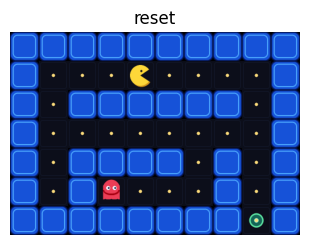

In [3]:
# Concrete observations are image-like tensors: coins + agent channels + ghost channels.
raw_env = MiniPacmanWithCoins(render_mode="rgb_array")
obs, info = raw_env.reset(seed=0)
abstract_state = safety_abstraction(obs)

print("Concrete observation shape:", obs.shape)
print("Concrete observation space:", raw_env.observation_space)
print("Number of abstract safety states:", coins.N_STATES)
print("Initial abstract safety state:", abstract_state)
print("Decoded abstract state tuple:", coins.REVERSE_STATE_MAP[int(abstract_state)])
print("Concrete labels:", label_fn(obs))
print("Abstract labels:", abstr_label_fn(int(abstract_state)))
print("Cost:", cost_fn(label_fn(obs)))
show_frames([raw_env.render()], ["reset"])

## State-space reduction

The full task observation carries reward-relevant coin information. The shield only needs the safety-relevant variables: agent position/direction and ghost position/direction. In this environment, `safety_abstraction(obs)` maps the concrete observation tensor to one of the tabular Pacman safety states.

In [4]:
# Concrete state count is not finite in the same tabular sense because the public observation includes a coin bitmap.
# A simple upper bound counts all binary coin configurations times the abstract Pacman safety states.
coin_cells = int(np.prod(coins.STANDARD_MAP.shape))
abstract_states = int(coins.N_STATES)
upper_bound_full_states = abstract_states * (2 ** coin_cells)

print(f"Grid cells that may appear in the coin bitmap: {coin_cells}")
print(f"Abstract safety states: {abstract_states:,}")
print(f"Naive upper bound with all binary coin configurations: {abstract_states:,} * 2^{coin_cells} = {upper_bound_full_states:.3e}")
print(f"Reduction factor relative to that upper bound: about 2^{coin_cells}")

Grid cells that may appear in the coin bitmap: 70
Abstract safety states: 4,624
Naive upper bound with all binary coin configurations: 4,624 * 2^70 = 5.459e+24
Reduction factor relative to that upper bound: about 2^70


Initial concrete observation shape: (7, 10, 9)
Initial abstract state: 667
{'labels': set(),
 'constraint': {'type': 'CMDP',
                'step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}},
 'constraint.step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}}


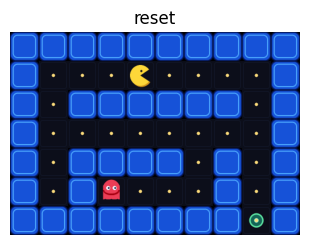

In [6]:
# We can still construct the environment through MASA's make_env.
# Because the observation space is Box, the shield/probabilistic wrapper later receives `safety_abstraction` explicitly.

def make_pacman_coins_env(max_episode_steps: int = 40, seed: int = 0):
    env = make_env(
        "MiniPacmanWithCoins",
        "CMDP",
        max_episode_steps,
        label_fn=label_fn,
        constraint_kwargs={"cost_fn": cost_fn, "budget": 0.0},
        env_kwargs={"render_mode": "rgb_array"},
    )
    obs, info = env.reset(seed=seed)
    return env, obs, info

env, obs, info = make_pacman_coins_env(seed=2)
print("Initial concrete observation shape:", np.asarray(obs).shape)
print("Initial abstract state:", safety_abstraction(obs))
pprint.pp(compact_info(info))
show_frames([render_frame(env)], ["reset"])

{'t': 1,
 'action': 0,
 'concrete_obs_shape': (7, 10, 9),
 'abstract_state': 805,
 'decoded_abstract_state': (1, 5, 1, 5, 4, 1, 0),
 'concrete_labels': [],
 'abstract_labels': [],
 'cost': 0.0,
 'reward': 1.0,
 'terminated': False,
 'truncated': False,
 'compact_info': {'labels': set(),
                  'constraint': {'type': 'CMDP', 'step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}},
                  'constraint.step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}}}
------------------------------------------------------------------------------------------------------------------------
{'t': 2,
 'action': 1,
 'concrete_obs_shape': (7, 10, 9),
 'abstract_state': 941,
 'decoded_abstract_state': (1, 6, 1, 5, 4, 1, 0),
 'concrete_labels': [],
 'abstract_labels': [],
 'cost': 0.0,
 'reward': 1.0,
 'terminated': False,
 'truncated': False,
 'compact_info': {'labels': set(),
                  'constraint': {'type': 'CMDP', 'step': {'cost': 0.0, 'violation': 0.0, 'cum_cost': 0.0}},

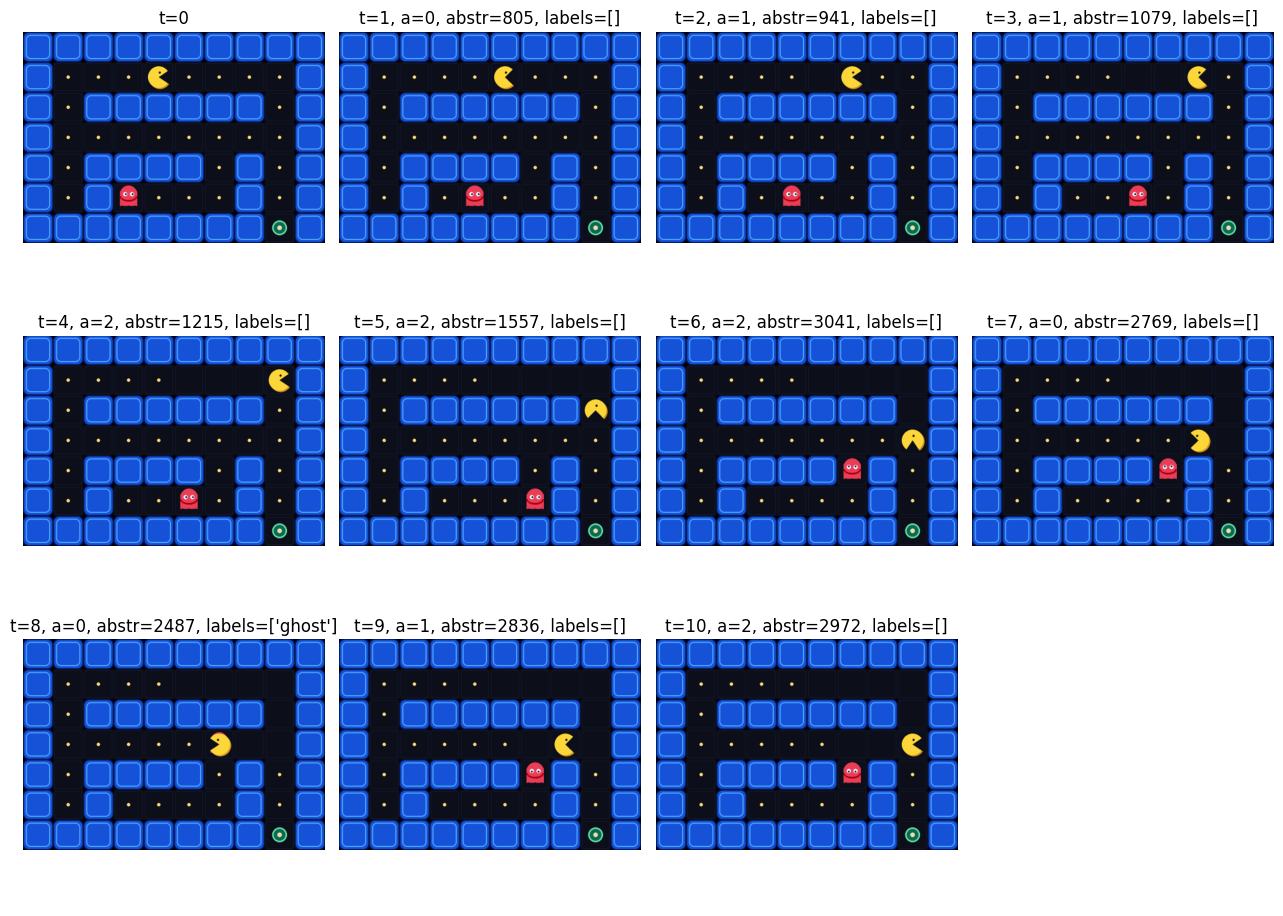

In [9]:
# Step through the concrete environment while logging the safety abstraction.
action_script = [0, 1, 1, 2, 2, 2, 0, 0, 1, 2]
frames, titles, rows = [], [], []
obs, info = env.reset(seed=4)
frames.append(render_frame(env))
titles.append("t=0")

for t, action in enumerate(action_script, start=1):
    next_obs, reward, terminated, truncated, info = env.step(action)
    abstr = int(safety_abstraction(next_obs))
    row = {
        "t": t,
        "action": action,
        "concrete_obs_shape": tuple(np.asarray(next_obs).shape),
        "abstract_state": abstr,
        "decoded_abstract_state": coins.REVERSE_STATE_MAP[abstr],
        "concrete_labels": sorted(label_fn(next_obs)),
        "abstract_labels": sorted(abstr_label_fn(abstr)),
        "cost": float(cost_fn(label_fn(next_obs))),
        "reward": float(reward),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "compact_info": compact_info(info),
    }
    rows.append(row)
    frames.append(render_frame(env))
    titles.append(f"t={t}, a={action}, abstr={abstr}, labels={sorted(label_fn(next_obs))}")
    obs = next_obs
    if terminated or truncated:
        break

for row in rows:
    pprint.pp(row, width=150)
    print("-" * 120)

show_frames(frames, titles)

**Talking point.** The task learner may need the full coin observation to optimize reward, but the safety shield can operate on a much smaller abstraction as long as the abstraction is conservative for the safety property.